Original labels: [1, 2, 3, 4, 5, 6]
Encoded labels: [0 1 2 3 4 5]
Train shape: (640, 16)
Val shape: (160, 16)

Model: Logistic Regression
Accuracy: 0.3500
Macro F1: 0.3273

Classification Report:
              precision    recall  f1-score   support

           1       0.47      0.31      0.37        26
           2       0.38      0.11      0.17        28
           3       0.34      0.56      0.42        27
           4       0.29      0.21      0.24        28
           5       0.35      0.65      0.46        26
           6       0.32      0.28      0.30        25

    accuracy                           0.35       160
   macro avg       0.36      0.35      0.33       160
weighted avg       0.36      0.35      0.32       160


Model: SVM (RBF)
Accuracy: 0.3125
Macro F1: 0.2950

Classification Report:
              precision    recall  f1-score   support

           1       0.40      0.23      0.29        26
           2       0.40      0.14      0.21        28
           3       0.2

,model,accuracy,macro_precision,macro_recall,macro_f1
3,XGBoost,0.35000,0.351309,0.349825,0.341527
2,Random Forest,0.33125,0.331548,0.332260,0.328808
0,Logistic Regression,0.35000,0.357427,0.353087,0.327254
1,SVM (RBF),0.31250,0.321763,0.311107,0.295014



Best Model: XGBoost

Cross Validation (SVM best check)
CV F1 Macro Scores: [0.30029667 0.30122159 0.36518477 0.26669865 0.38773679]
Mean CV F1: 0.3242276949678612


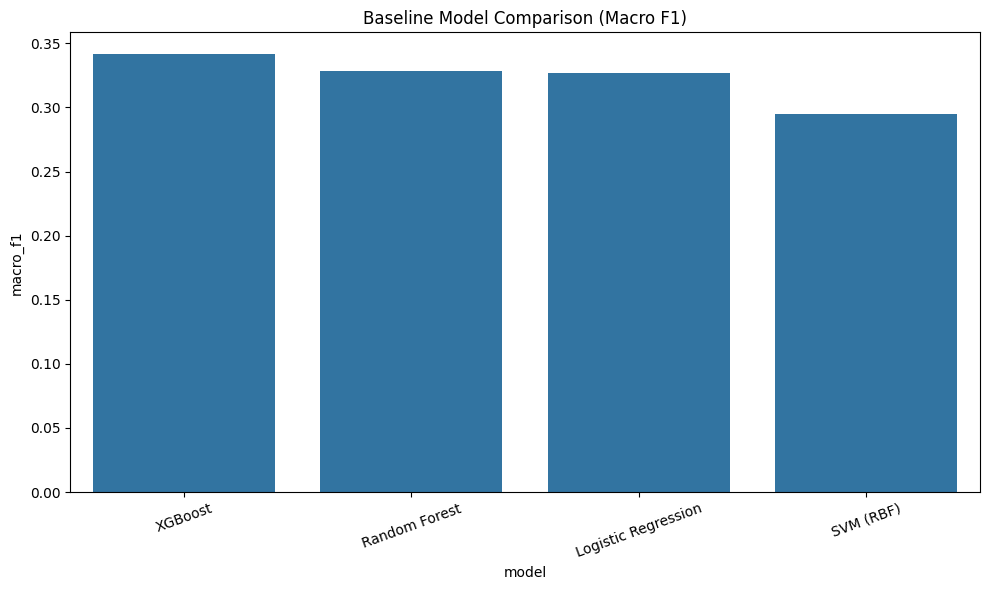

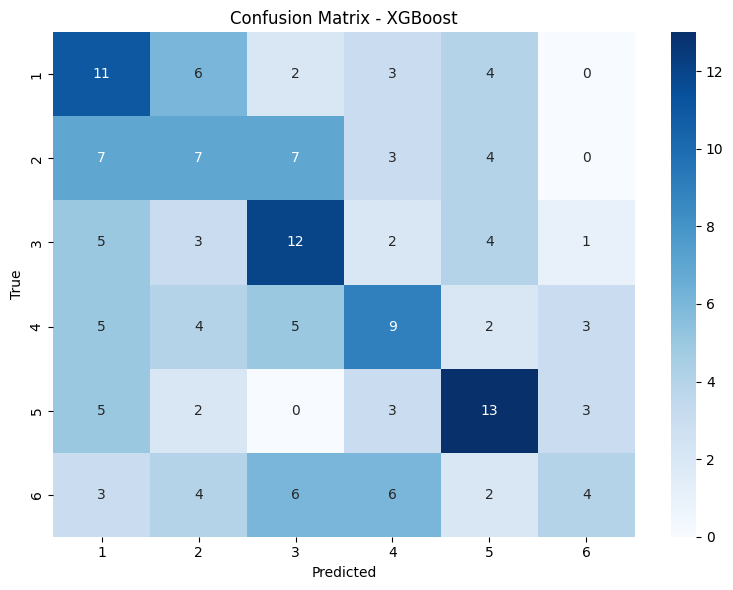


FINAL SUMMARY
Best Model: XGBoost
Best Macro F1: 0.34152674303940933
Best Accuracy: 0.35

DONE ✔


In [1]:
# =========================================
# 03 - Baseline Models (IMPROVED VERSION)
# =========================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 1. PATHS
# =========================================

BASE_PATH = r"C:\Users\Neda\Desktop\personality_llm"

FEATURES_PATH = os.path.join(BASE_PATH, "data", "features")
RESULTS_PATH = os.path.join(BASE_PATH, "results")
MODELS_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# =========================================
# 2. LOAD DATA
# =========================================

X = pd.read_csv(os.path.join(FEATURES_PATH, "X_train.csv"))
y_raw = pd.read_csv(os.path.join(FEATURES_PATH, "y_train.csv")).squeeze()

print("Original labels:", sorted(y_raw.unique()))

# =========================================
# 3. LABEL ENCODING (SAFE)
# =========================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Encoded labels:", np.unique(y))

# =========================================
# 4. TRAIN / VALID SPLIT
# =========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

# =========================================
# 5. MODELS (BASELINE SET)
# =========================================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]),

    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(np.unique(y)),
        eval_metric="mlogloss",
        random_state=42
    )
}

# =========================================
# 6. TRAIN + EVALUATION
# =========================================

results = []
trained_models = {}

for name, model in models.items():
    print("\n==============================")
    print("Model:", name)
    print("==============================")

    # Fit
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_val, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)

    results.append({
        "model": name,
        "accuracy": acc,
        "macro_precision": prec,
        "macro_recall": rec,
        "macro_f1": f1
    })

    trained_models[name] = model

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=[str(c) for c in label_encoder.classes_],
        zero_division=0
    ))

# =========================================
# 7. RESULTS TABLE
# =========================================

results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)

print("\n==============================")
print("FINAL COMPARISON")
print("==============================")

display(results_df)

results_df.to_csv(
    os.path.join(RESULTS_PATH, "baseline_results.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================
# 8. BEST MODEL
# =========================================

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)

joblib.dump(best_model, os.path.join(MODELS_PATH, "best_baseline_model.pkl"))
joblib.dump(label_encoder, os.path.join(MODELS_PATH, "label_encoder.pkl"))

# =========================================
# 9. CROSS VALIDATION (IMPORTANT FOR THESIS)
# =========================================

print("\n==============================")
print("Cross Validation (SVM best check)")
print("==============================")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = models["SVM (RBF)"]

cv_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("CV F1 Macro Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

# =========================================
# 10. VISUALIZATION
# =========================================

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="model", y="macro_f1")
plt.title("Baseline Model Comparison (Macro F1)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_PATH, "baseline_comparison.png"), dpi=300)
plt.show()

# =========================================
# 11. CONFUSION MATRIX (BEST MODEL)
# =========================================

y_best_pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "confusion_matrix_best.png"), dpi=300)
plt.show()

# =========================================
# 12. FINAL REPORT
# =========================================

final_report = classification_report(
    y_val,
    y_best_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(final_report).transpose()

report_df.to_csv(
    os.path.join(RESULTS_PATH, "best_model_report.csv"),
    encoding="utf-8-sig"
)

print("\n==============================")
print("FINAL SUMMARY")
print("==============================")
print("Best Model:", best_model_name)
print("Best Macro F1:", results_df.iloc[0]["macro_f1"])
print("Best Accuracy:", results_df.iloc[0]["accuracy"])
print("\nDONE ✔")